## Problem 2 part a

In [6]:
import numpy as np

# Observed data
my_wins = 4
my_ties = 2
my_loss = 1
n_games = my_wins + my_ties + my_loss

obs_T = 1*my_wins + 0*my_ties + (-1)*my_loss

n_sim = 2000

all_null_Ts = np.zeros(n_sim)

for cur_sim in range(n_sim):
    outcome = np.random.choice([1, 0, -1], size=n_games, replace=True, p=[1/3, 1/3, 1/3])
    all_null_Ts[cur_sim] = np.sum(outcome)

# Calculate simulated p-value
p_value = np.mean(all_null_Ts >= obs_T)
print(f"Simulated p-value: {p_value}")

Simulated p-value: 0.136


## Problem 2 part b

In [9]:
import numpy as np

# Observed data
my_wins = 4
my_ties = 2
my_loss = 1
n_games = my_wins + my_ties + my_loss

obs_T = 2*my_wins + 0*my_ties + (-1)*my_loss

n_sim = 2000
all_null_Ts = np.zeros(n_sim)

for cur_sim in range(n_sim):
    outcome = np.random.choice([2, 0, -1], size=n_games, replace=True, p=[1/3, 1/3, 1/3])
    all_null_Ts[cur_sim] = np.sum(outcome)

# Calculate simulated p-value
p_value = np.mean(all_null_Ts >= obs_T)

print(f"Simulated p-value: {p_value}")

Simulated p-value: 0.1105


## Problem 3 part a

Simulated p-value: 0.030666666666666665


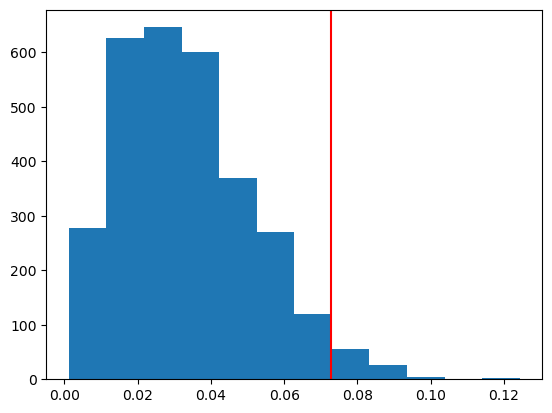

In [14]:
import numpy as np

n_sim = 3000

## Observed data
my_viewsA = 60
my_viewsB = 31
my_viewsC = 41
all_views = my_viewsA + my_viewsB + my_viewsC

n_impsA = 160
n_impsB = 120
n_impsC = 150
all_imps = n_impsA + n_impsB + n_impsC

## Calculate CTRs
obs_CTRs = np.array([my_viewsA / n_impsA, my_viewsB / n_impsB, my_viewsC / n_impsC])
obs_T = np.max(obs_CTRs) - np.mean(obs_CTRs)

# Simulate outcomes
all_null_Ts = np.zeros(n_sim)

for cur_sim in range(n_sim):
    pool = np.concatenate((np.ones(all_views), np.zeros(all_imps - all_views)))

    idxA = np.random.choice(len(pool), n_impsA, replace=False)
    impsA = pool[idxA]
    viewsA = int(np.sum(impsA))

    maskA = np.ones(len(pool), dtype=bool)
    maskA[idxA] = False
    pool = pool[maskA]  

    idxB = np.random.choice(len(pool), n_impsB, replace=False)
    impsB = pool[idxB]                          # ✅ FILL IN
    viewsB = int(np.sum(impsB))
    
    viewsC = int(all_views - viewsA - viewsB)

    null_CTRs = np.array([viewsA / n_impsA, viewsB / n_impsB, viewsC / n_impsC])
    null_T = np.max(null_CTRs) - np.mean(null_CTRs)
    all_null_Ts[cur_sim] = null_T

# Calculate simulated p-value
p_value = np.mean(all_null_Ts >= obs_T)
print(f"Simulated p-value: {p_value}")

# plot the distribution of null T's
import matplotlib.pyplot as plt
plt.hist(all_null_Ts, bins=12)
plt.axvline(obs_T, color='red')
plt.show()


## Problem 4

Using the boostrap, calculate a 95% confidence interval for the correlation between `price` and `yr_built` from the Rainier Valley House dataset. 

Correlation from data:
0.1112814486170098
Bootstrap standard deviation: 0.04880113863267963
Bootstrap 95% confidence interval: (np.float64(0.013679171351650532), np.float64(0.20888372588236906))


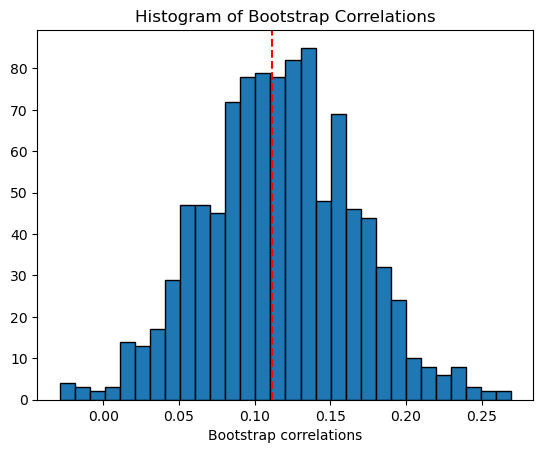

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
house = pd.read_csv("rainier_valley_house.csv")

X = house[['price', 'yr_built']].values
n = len(X)

obs_corr = np.corrcoef(X[:, 0], X[:, 1])[0, 1]
print("Correlation from data:")
print(obs_corr)

n_sim = 1000

all_corrs = np.zeros(n_sim)

# Perform bootstrap simulations
for cur_sim in range(n_sim):
    boot_idx = np.random.choice(n, n, replace=True)
    Xboot =  X[boot_idx]
    all_corrs[cur_sim] = np.corrcoef(Xboot[:, 0], Xboot[:, 1])[0, 1]

print(f"Bootstrap standard deviation: {np.std(all_corrs)}")
print(f"Bootstrap 95% confidence interval: {(obs_corr - 2*np.std(all_corrs), obs_corr + 2*np.std(all_corrs))}")

plt.hist(all_corrs, bins=30, edgecolor='black')
plt.xlabel('Bootstrap correlations')
plt.title('Histogram of Bootstrap Correlations')
plt.axvline(x=obs_corr, color='r', linestyle='--')
plt.show()
